# 03 - OpenEnv RL Environment Demo & Reward System Breakdown

This notebook demonstrates:
1. Initializing and resetting `GPUSchedulerEnvironment` / `OpenEnvClient`.
2. Inspecting the observation vector breakdown (Node features, Queue features, Global features).
3. Visualizing 2D Action Masking (`[max_queue_size, num_nodes]`).
4. Stepping through scheduling actions with a detailed live printout of shaped reward terms:
   $$R_t = + R_{\text{completion}} - C_{\text{wait}} - C_{\text{idle}} - C_{\text{deadline}} - C_{\text{invalid}}$$

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in python path
sys.path.insert(0, os.path.abspath('..'))

from env.server.gpu_scheduler_environment import GPUSchedulerEnvironment
from env.client import OpenEnvClient

print("OpenEnv Environment imported successfully!")

OpenEnv Environment imported successfully!


## 1. Initialize Environment and Inspect Reward Configuration

In [2]:
env = GPUSchedulerEnvironment(
    cluster_config_path="../configs/cluster_small.yaml",
    reward_config_path="../configs/reward.yaml",
    scenario_name="balanced",
    max_queue_size=16,
    horizon_seconds=1800.0
)

print("=== Environment Specs ===")
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Num Nodes: {env.num_nodes}, Max Queue Size: {env.max_queue_size}")
print(f"Total Action Dimensions: {env.action_dim}")
print(f"Total Observation Dimensions: {env.obs_dim}")

print("\n=== Reward Coefficients (configs/reward.yaml) ===")
for k, v in env.reward_config.items():
    print(f"  {k:25s}: {v}")

=== Environment Specs ===
Action Space: Discrete(32)
Observation Space: Box(0.0, 10.0, (164,), float32)
Num Nodes: 2, Max Queue Size: 16
Total Action Dimensions: 32
Total Observation Dimensions: 164

=== Reward Coefficients (configs/reward.yaml) ===
  completion_weight        : 2.0
  waiting_weight           : 0.005
  idle_gpu_weight          : 0.02
  deadline_miss_weight     : 3.0
  invalid_action_penalty   : 1.5
  starvation_penalty_weight: 0.05
  step_penalty             : 0.001


## 2. Environment Reset & Observation Vector Inspection

In [3]:
obs, info = env.reset(seed=42)

print(f"Initial Observation Vector Shape: {obs.shape}")
print(f"Initial Queue Length: {len(env.simulator.queue)}")
print(f"Simulation Time: {env.simulator.current_time:.2f}s")

# Breakdown of observation vector parts
node_part_len = env.num_nodes * env.node_feat_dim
queue_part_len = env.max_queue_size * env.queue_feat_dim

print(f"\nObservation Vector Breakdown:")
print(f"  - Node Features ({env.num_nodes} nodes x {env.node_feat_dim}): indices [0 : {node_part_len}]")
print(f"  - Queue Features ({env.max_queue_size} slots x {env.queue_feat_dim}): indices [{node_part_len} : {node_part_len + queue_part_len}]")
print(f"  - Global Features ({env.global_feat_dim}): indices [{node_part_len + queue_part_len} : {len(obs)}]")

print("\nGlobal Features Values [sim_time_norm, queue_len_norm, cluster_gpu_util, cluster_vram_util]:")
print(obs[node_part_len + queue_part_len:])

Initial Observation Vector Shape: (164,)
Initial Queue Length: 1
Simulation Time: 28.85s

Observation Vector Breakdown:
  - Node Features (2 nodes x 8): indices [0 : 16]
  - Queue Features (16 slots x 9): indices [16 : 160]
  - Global Features (4): indices [160 : 164]

Global Features Values [sim_time_norm, queue_len_norm, cluster_gpu_util, cluster_vram_util]:
[0.01602778 0.0625     0.         0.        ]


## 3. Action Masking Demonstration

In [4]:
mask_2d = env.get_action_mask_2d()
df_mask = pd.DataFrame(
    mask_2d,
    index=[f"QueueSlot_{i}" for i in range(env.max_queue_size)],
    columns=[f"Node_{j} ({env.cluster.nodes[j].gpu_type})" for j in range(env.num_nodes)]
)

print("Action Feasibility Mask (1.0 = Valid Placement, 0.0 = Infeasible):")
print(df_mask.head(8))  # Display first 8 queue slots

Action Feasibility Mask (1.0 = Valid Placement, 0.0 = Infeasible):
             Node_0 (A100_40GB)  Node_1 (A10_24GB)
QueueSlot_0                 1.0                1.0
QueueSlot_1                 0.0                0.0
QueueSlot_2                 0.0                0.0
QueueSlot_3                 0.0                0.0
QueueSlot_4                 0.0                0.0
QueueSlot_5                 0.0                0.0
QueueSlot_6                 0.0                0.0
QueueSlot_7                 0.0                0.0


## 4. Stepping Through Simulation with Live Reward Diagnostics

In [5]:
print("Running 15 Step Demo with live reward inspection...\n")
print("-" * 85)
print(f"{'Step':<5} | {'Action (Job,Node)':<18} | {'Valid?':<6} | {'Reward':<8} | {'SimTime':<8} | {'QueueLen':<8} | {'GPU Util':<8}")
print("-" * 85)

step_rewards = []
gpu_utils = []
queue_lengths = []

for step_i in range(15):
    mask = env.get_action_mask()
    valid_indices = np.where(mask > 0)[0]
    
    if len(valid_indices) == 0:
        print(f"Step {step_i:02d}: No valid actions available.")
        break
        
    # Select first valid action
    action = int(valid_indices[0])
    j_idx, n_idx = env.decode_action(action)
    
    obs, reward, term, trunc, step_info = env.step(action)
    
    step_rewards.append(reward)
    gpu_utils.append(env.cluster.gpu_utilization * 100)
    queue_lengths.append(len(env.simulator.queue))
    
    print(
        f"{step_i:<5d} | "
        f"Slot {j_idx} -> Node {n_idx:<4d} | "
        f"{str(step_info['valid_action']):<6s} | "
        f"{reward:+7.3f} | "
        f"{step_info['sim_time']:6.1f}s | "
        f"{len(env.simulator.queue):<8d} | "
        f"{env.cluster.gpu_utilization*100:6.1f}%"
    )
    
    if term or trunc:
        print("Episode finished!")
        break

print("-" * 85)
print(f"Total Cumulative Reward: {sum(step_rewards):.3f}")

Running 15 Step Demo with live reward inspection...

-------------------------------------------------------------------------------------
Step  | Action (Job,Node)  | Valid? | Reward   | SimTime  | QueueLen | GPU Util
-------------------------------------------------------------------------------------
0     | Slot 0 -> Node 0    | True   |  +1.964 |   47.8s | 3        |    0.0%
1     | Slot 0 -> Node 0    | True   |  -0.039 |   61.6s | 4        |   12.5%
2     | Slot 3 -> Node 0    | True   |  -0.039 |   71.7s | 5        |   37.5%
3     | Slot 4 -> Node 1    | True   |  -0.053 |  123.3s | 9        |   62.5%
4     | Slot 8 -> Node 0    | True   |  +3.937 |  146.6s | 10       |   37.5%
5     | Slot 8 -> Node 0    | True   |  -0.066 |  149.6s | 11       |   50.0%
6     | Slot 10 -> Node 1    | True   |  -0.069 |  167.4s | 12       |   62.5%
7     | Slot 11 -> Node 1    | True   |  +1.919 |  200.6s | 14       |   50.0%
8     | Slot 4 -> Node 0    | True   |  +1.921 |  215.5s | 14       |

## 5. Live Reward & Resource Dynamics Plot

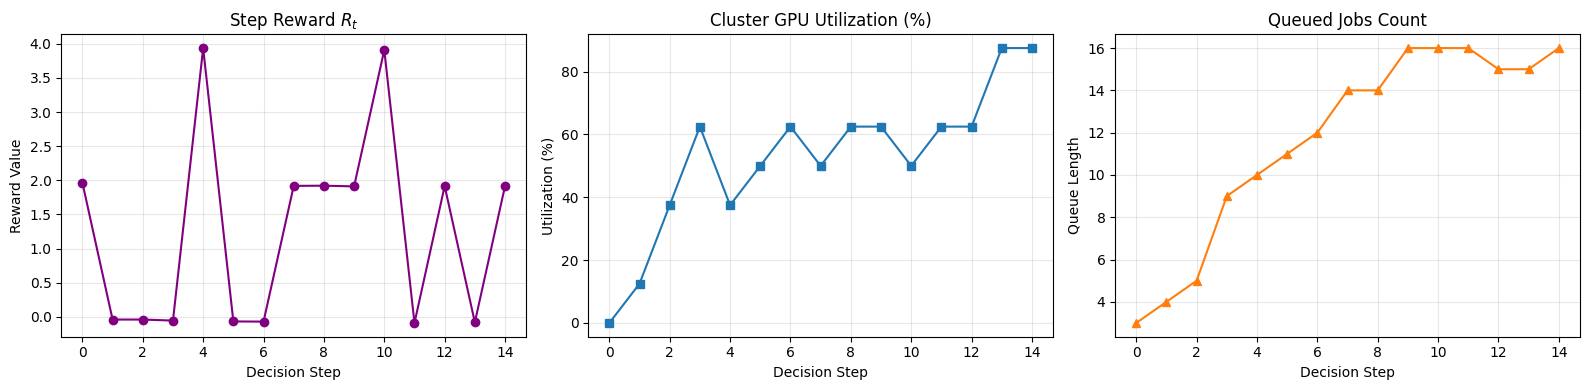

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(step_rewards, marker='o', color='purple')
ax1.set_title("Step Reward $R_t$")
ax1.set_xlabel("Decision Step")
ax1.set_ylabel("Reward Value")
ax1.grid(True, alpha=0.3)

ax2.plot(gpu_utils, marker='s', color='tab:blue')
ax2.set_title("Cluster GPU Utilization (%)")
ax2.set_xlabel("Decision Step")
ax2.set_ylabel("Utilization (%)")
ax2.grid(True, alpha=0.3)

ax3.plot(queue_lengths, marker='^', color='tab:orange')
ax3.set_title("Queued Jobs Count")
ax3.set_xlabel("Decision Step")
ax3.set_ylabel("Queue Length")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()